# Rocks neg masking

First approach: 
- Check the data to find rocks, then look at the closeup of that photo
  - I believe rocks should be inferable without extra context
  - side thought: context can be something like a single number that my classifier returns
   - Like, run a classifier on the bigger tile
   - this tells the "context"
   - run classifier on smaller tile with this context variable attached to the last layer maybe?
   - Currently I will make context concrete myself, you can technially have the model define context itself, the goal would be difficult to make here (this is similar to how instead of concrete embeddings, the models puts words in an embedding space and decides what that word itself means)
- First we need data (can google and get i think)

It is useful to somehow decrease the scope of images. I'm reasonably sure I can get the data I want from mapillary.   
How can I go about this? How do I increase the speed of annotation

- I would want to somehow find examples where only rocks exist, run my model, get each mask and its associated image. ALL would be marked rocks in this
- How do I rocks fast in my dataset?

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random
from mtrain.utils import mkdir
import json
from PIL import Image
from pycocotools import mask as mask_utils
from tqdm import tqdm
from mtrain.disk import DiskBooleanMask, DiskImage
import itertools

In [4]:
DS = Path("../../datasets/")
BASE = DS / "test-samples"
NEG_MASKING_V1 = BASE / "neg-masking" / "V1"
ROCKS = NEG_MASKING_V1 / "rocks"
SAMPLES_MAPILLARY = NEG_MASKING_V1 / "samples_mapillary"
ROCKS_TXT_FILE = ROCKS / "clip_query_res.txt"
ROCKS_DATA_DIR = mkdir(ROCKS / "data")
ROCKS_CVAT_DIR = mkdir(ROCKS / "cvat")

SAMPLES_MAPILLARY.exists(), ROCKS.exists()

(True, True)

In [5]:
def read_clip_file(path):
    with open(path) as f:
        lines = f.readlines()
    imgs = [Path(line.split("\t")[1]) for line in lines]
    dirs = [img.parent for img in imgs]
    return dirs

# extract dataset using clip

using clip worked
first query using clip in our existing dataset
we find rock images with this. This is quite good actually. Now I just need to isolate the masks into regions (using cv2)
then decide which mask to keep and which to not. This can be done in label studio
This is not bad
do i even need to train a model which differentiates between rocks and garbage? 
Idts, this is the first thing we train our model on then

In [148]:
import os


def mk_symlink(p):
    os.symlink(
        f"../../samples_mapillary/100/{p.name}", p, target_is_directory=True
    )

In [149]:
dirs = read_clip_file(ROCKS_TXT_FILE)

In [150]:
import shutil

data = ROCKS_DATA_DIR

shutil.rmtree(data)
data = mkdir(data)
for d in dirs:
    p = data / d.name
    mk_symlink(p)

# CVAT export

In [151]:
def all_files_exist_in_dir(*fnames):
    def wrapped(d):
        for fname in fnames:
            if not (d / fname).exists():
                return False
        return True
    return wrapped

def get_images_and_masks(clip_file_path, mask_name, image_name="image.jpg"):
    dirs = read_clip_file(clip_file_path)
    it = filter(all_files_exist_in_dir(image_name, mask_name), dirs)
    suff = Path(image_name).suffix
    for d in it:
        mask = DiskBooleanMask.load(d / mask_name)
        img = DiskImage.load(d / image_name)
        yield f"{d.name}{suff}", img, mask

figsize (10, 10)


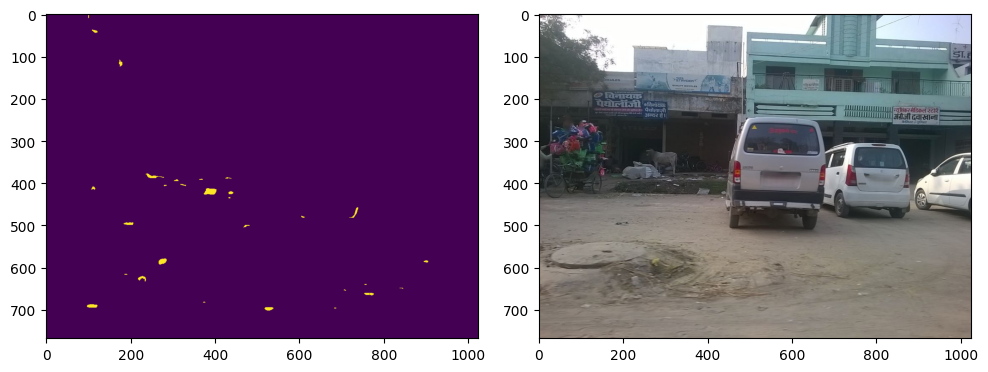

In [5]:
m= DiskBooleanMask.load("/Users/hariomnarang/Desktop/personal/roads/datasets/test-samples/neg-masking/V1/rocks/data/1025399437994120/m1.png")
im = DiskImage.load("/Users/hariomnarang/Desktop/personal/roads/datasets/test-samples/neg-masking/V1/rocks/data/1025399437994120/image.jpg")
from mtrain.utils import show
show([m, im])

In [6]:
import shutil
from mtrain.cvat.export import export_cvat_task_backup, export_cvat_annotations

shutil.rmtree(ROCKS_CVAT_DIR, True)

MAX_SAMPLES = 400
def _get_iter():
    return itertools.islice(get_images_and_masks(ROCKS_TXT_FILE, "m1.png"), MAX_SAMPLES)

export_cvat_annotations(
    _get_iter(),
    {0: "background", 1: "trash"},
    ROCKS_CVAT_DIR,
    total=MAX_SAMPLES,
)
export_cvat_task_backup(_get_iter(), "Rocks", ROCKS_CVAT_DIR, total=MAX_SAMPLES)

Exporting annotations: 100%|██████████| 400/400 [00:36<00:00, 11.09img/s]



Done. 400 images, 14506 annotations.
  annotations.json  →  /Users/hariomnarang/Desktop/personal/roads/datasets/test-samples/neg-masking/V1/rocks/cvat/annotations.json

Upload: task → Actions → Upload Annotations → COCO 1.0 → /Users/hariomnarang/Desktop/personal/roads/datasets/test-samples/neg-masking/V1/rocks/cvat/annotations.json


Exporting images: 100%|██████████| 400/400 [00:07<00:00, 56.79img/s]



Done. 400 images  →  /Users/hariomnarang/Desktop/personal/roads/datasets/test-samples/neg-masking/V1/rocks/cvat/task.zip

Upload: CVAT → Create task from backup → upload task.zip


PosixPath('../../datasets/test-samples/neg-masking/V1/rocks/cvat')

Exporting images: 100%|██████████| 5/5 [00:00<00:00, 102.08img/s]


Done. 5 images  →  /Users/hariomnarang/Desktop/personal/roads/datasets/test-samples/neg-masking/V1/rocks/cvat/task/task.zip

Upload: CVAT → Create task from backup → upload task.zip


PosixPath('../../datasets/test-samples/neg-masking/V1/rocks/cvat/task')

# Rocks sample small photos

Given a mask and an image from the model, we take images we know have a lot of rocks.  
In these photos, we take a crop of detected objects (wherever we have a mask).  
Run a classifier which says whether that mask is a stone/rock or something else. How do we handle sizes? We pad the input and pass to model when the size is small. We use a model of size 100

In [6]:
from mtrain.neg_mask.widget_2 import LabelWidget, Bbox, parse_crop_level_ds, parse_top_level_ds

In [16]:
def get_region_crops(img, mask, padding=20):
    _, labels = cv2.connectedComponents(mask)
    h, w = img.shape[:2]
    for label in range(1, labels.max() + 1):
        rows, cols = np.where(labels == label)
        r1 = max(0, rows.min())
        r2 = min(h, rows.max())
        c1 = max(0, cols.min())
        c2 = min(w, cols.max())
        yield Bbox(c1, r1, c2-c1, r2-r1)

In [17]:
dirs = read_clip_file(ROCKS_TXT_FILE)

In [31]:
def get_crops(dirs):
    for d in dirs:
        img = DiskImage.load(d / "image.jpg")
        mask = DiskBooleanMask.load(d / "m2.png")
        for _, im, msk in get_region_crops(img, mask, 50):
            yield d.name, im, msk

In [90]:
widget = LabelWidget(ROCKS / "classification")

def is_dir_not_done(direc: Path):
    return not widget.is_done(direc.name)

dir_it = filter(is_dir_not_done, iter(dirs))

# run the cell below for vscode color theme support in ipywidgets

# Source - https://stackoverflow.com/a/77028015
# Posted by Yingding Wang, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-02, License - CC BY-SA 4.0

In [51]:
%%html

<style>
/*overwrite hard coded write background by vscode for ipywidges */
.cell-output-ipywidget-background {
   background-color: transparent !important;
}

/*set widget foreground text and color of interactive widget to vs dark theme color */
:root {
    --jp-widgets-color: var(--vscode-editor-foreground);
    --jp-widgets-font-size: var(--vscode-editor-font-size);
}
</style>

In [174]:
d = next(dir_it)
img, mask = DiskImage.load(d / "image.jpg"), DiskBooleanMask.load(d / "m2.png")
bboxes = list(get_region_crops(img, mask))

widget.ui(d.name, bboxes, img, mask)

# Train model


In [ ]:
import torch
from fastai.vision.all import vision_learner

In [ ]:
def _is_valid_dir(direc: Path):
    valid = (
        (direc / "image.jpg").exists()
        and (direc / "mask.png").exists()
        and (direc / "out_mask.png").exists()
    )
    if not valid:
        print(
            f"WARN: directory: {direc} is not valid, it does not contain all required files"
        )
    return valid


class MaskFixDataset(torch.utils.data.Dataset):
    def __init__(
        self, dirs: list[Path | str], norm_stats: tuple[list[float], list[float]]
    ):
        self.mean = torch.tensor(norm_stats[0])
        self.std = torch.tensor(norm_stats[1])
        self.dirs = [d for d in map(Path, dirs) if _is_valid_dir(d)]

    def __len__(self):
        return len(self.dirs)

    # def __getit
    def __getitem__(self, index):
        d = self.dirs[index]
        img = torch.Tensor(DiskImage.load(d / "image.jpg"))
        img = img.permute(2, 0, 1).float() / 255.0
        img = (img - self.mean[:, None, None]) / self.std[:, None, None]
        mask = torch.Tensor(DiskBooleanMask.load(d / "mask.png"))
        mask = mask.float().unsqueeze(0)
        combined = torch.cat([img, mask], dim=0)
        out_mask = torch.Tensor(DiskBooleanMask.load(d / "out_mask.png"))

        # flipping, not doing rn, not very necessary for now
        # if random.random() > 0.5:
        #     combined = torch.flip(combined, dims=[-1])
        #     out_mask = torch.flip(out_mask, dims=[-1])

        return (combined, out_mask)